(140,)
(140,)


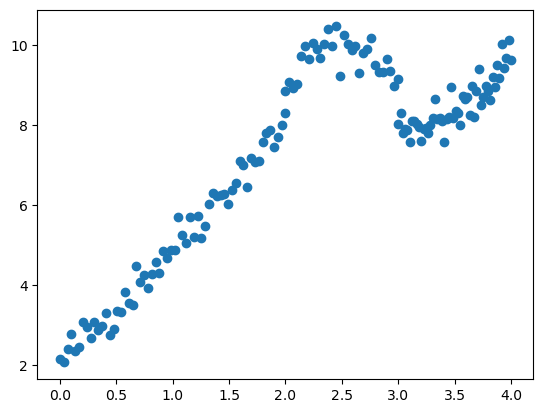

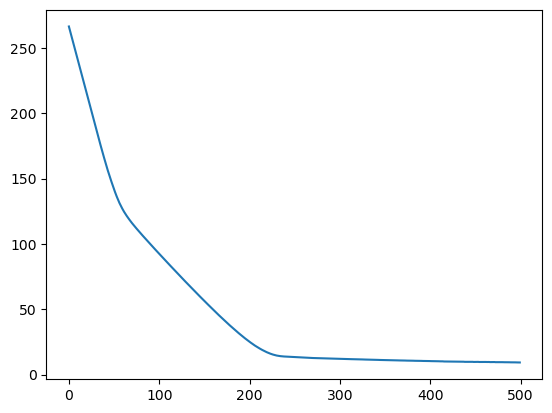

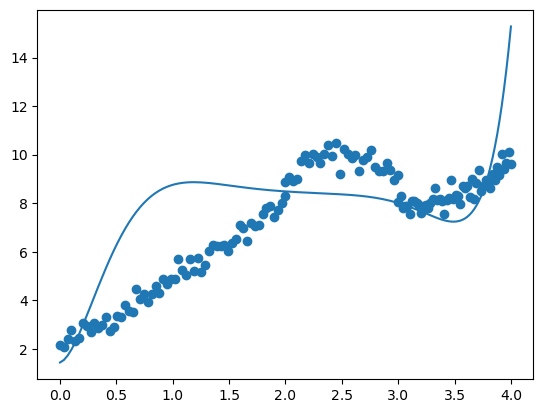

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("polynomial_data.csv")

x_train = data["x_train"].values
y_train = data["y_train"].values

print(x_train.shape) # (140,)
print(y_train.shape) # (140,)

plt.scatter(x_train, y_train)
plt.show()
x=x_train
y=y_train

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=8, include_bias=False)

X=x.reshape(-1,1)
y=y.reshape(-1,1)

x = (X - X.mean(axis=0))/X.std(axis=0)
x = poly.fit_transform(x)

w=np.random.randn(1,x.shape[1])
b=0
c=10
m = x.shape[0]
lr = 0.0001
epsilon_tube=1
loss_history=[]

for e in range(500):
    y_pred = x@w.T + b
    margin = np.maximum(0,np.abs(y_pred-y)-epsilon_tube)
    hinge_loss=c*np.mean(margin)
    total_loss=1/2*np.sum(np.square(w))+hinge_loss
    
    loss_history.append(total_loss)
    
    mask_pos=((y_pred-y)>0).flatten()
    mask_neg=((y_pred-y)<0).flatten()

    djdw = w + (c * (np.sum(x[mask_pos], axis=0,keepdims=True)) - c * np.sum(x[mask_neg], axis=0,keepdims=True)) / m
    djdb = c*(np.sum(mask_pos) - np.sum(mask_neg))

    w = w - lr * djdw
    b = b - lr * djdb

plt.plot(loss_history)
plt.show()
plt.scatter(X, y_train)
plt.plot(X,y_pred)
plt.show()

(140,)
(140,)


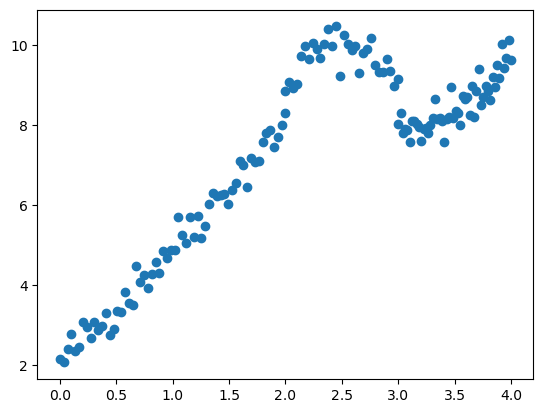

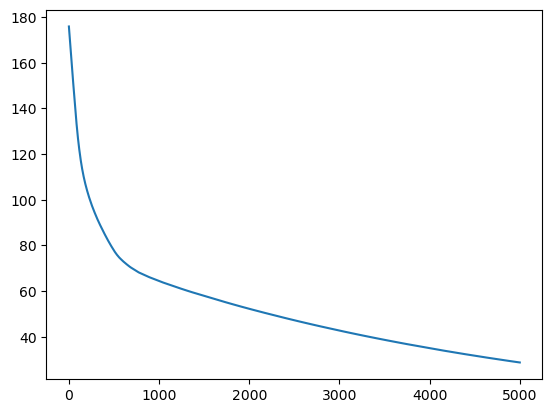

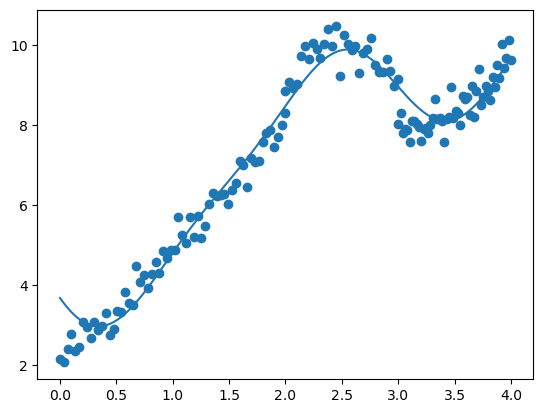

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("polynomial_data.csv")

x_train = data["x_train"].values
y_train = data["y_train"].values

print(x_train.shape) # (140,)
print(y_train.shape) # (140,)

plt.scatter(x_train, y_train)
plt.show()
x=x_train
y=y_train

def rbf_kernel(X1, X2, gamma=1.0):
    sq_dists = (
        np.sum(X1**2, axis=1).reshape(-1,1)
        + np.sum(X2**2, axis=1)
        - 2*np.dot(X1, X2.T)
    )
    return np.exp(-gamma * sq_dists)

X=x.reshape(-1,1)
y=y.reshape(-1,1)


x = rbf_kernel(X,X)
x = (x - x.mean(axis=0))/x.std(axis=0)

w=np.random.randn(1,x.shape[1])
b=0
c=10
m = x.shape[0]
lr = 0.0001
epsilon_tube=1
loss_history=[]

for e in range(5000):
    y_pred = x@w.T + b
    margin = np.maximum(0,np.abs(y_pred-y)-epsilon_tube)
    hinge_loss=c*np.mean(margin)
    total_loss=1/2*np.sum(np.square(w))+hinge_loss
    
    loss_history.append(total_loss)
    
    mask_pos=((y_pred-y)>0).flatten()
    mask_neg=((y_pred-y)<0).flatten()

    djdw = w + (c * (np.sum(x[mask_pos], axis=0,keepdims=True)) - c * np.sum(x[mask_neg], axis=0,keepdims=True)) / m
    djdb = c*(np.sum(mask_pos) - np.sum(mask_neg))

    w = w - lr * djdw
    b = b - lr * djdb

plt.plot(loss_history)
plt.show()
plt.scatter(X, y_train)
plt.plot(X,y_pred)
plt.show()